<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='cohort_month'>

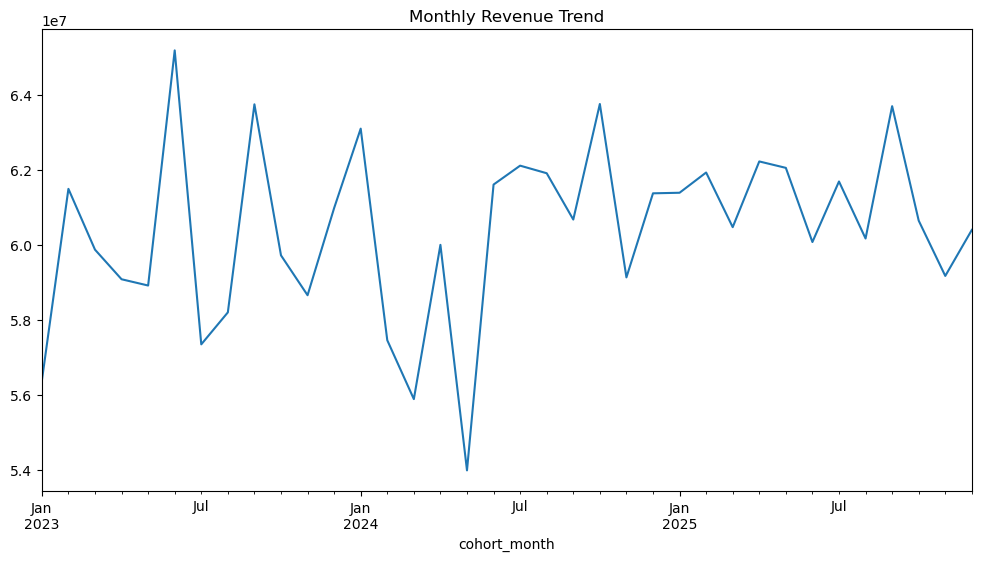

In [ ]:

import pandas as pd
df=pd.read_csv('indian_ecommerce.csv')


#                              1. Revenue Trends Over Time
# Convert orderdate (YYYY-MM-DD format from your data)
df['order_date'] = pd.to_datetime(df['order_date'])

# Add month-year cohort column
df['cohort_month'] = df['order_date'].dt.to_period('M')

#Identifies growth trajectory, seasonality, and anomalies
monthly_rev = df.groupby('cohort_month')['revenue'].sum()
monthly_rev.plot(title='Monthly Revenue Trend', figsize=(12,6))




               AOV (₹)  Avg Units  Order Count
discount_bin                                  
0-10%         60867.86      16.44          936
11-20%        66762.63      19.85         3958
21-30%        73397.90      25.50         5933
31-50%        75616.94      32.36        11213
50+%          66580.50      42.29         8560


C:\Users\HP\AppData\Local\Temp\ipykernel_27632\3449290921.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aov_analysis = df.groupby('discount_bin').agg({


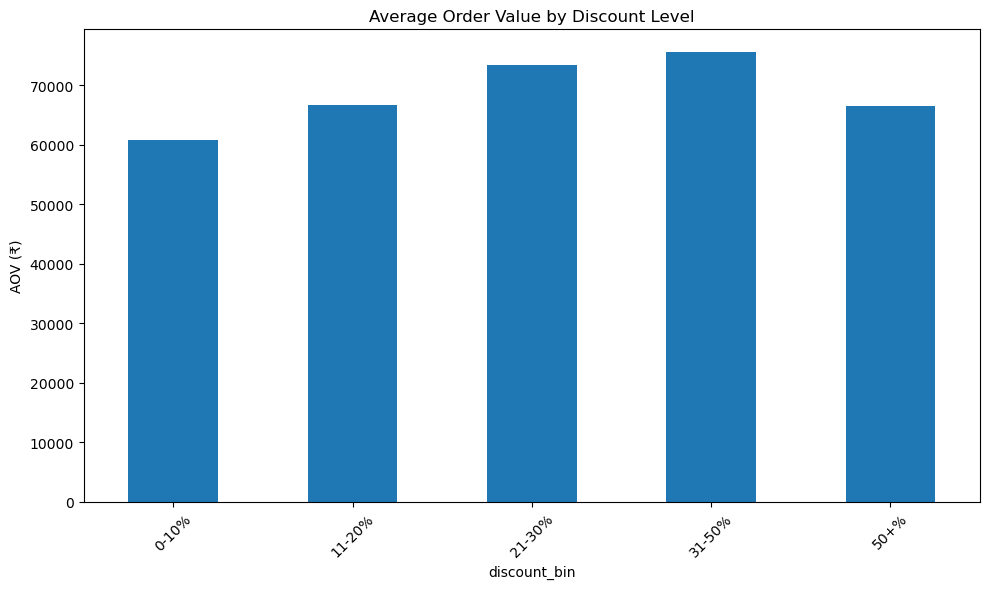

In [ ]:
#                              2. Pricing Impact Analysis


# Create discount bins
import matplotlib.pyplot as plt

df['discount_bin'] = pd.cut(df['discount_percent'], 
                           bins=[0, 10, 20, 30, 50, 100], 
                           labels=['0-10%', '11-20%', '21-30%', '31-50%', '50+%'])

# Calculate AOV (revenue per order)
aov_analysis = df.groupby('discount_bin').agg({
    'revenue': 'mean',           # Avg revenue per row/order
    'units_sold': 'mean',        # Avg units per order
    'order_id': 'count'          # Order volume
}).round(2)

aov_analysis.columns = ['AOV (₹)', 'Avg Units', 'Order Count']
print(aov_analysis)
aov_analysis['AOV (₹)'].plot(kind='bar', figsize=(10,6))
plt.title('Average Order Value by Discount Level')
plt.ylabel('AOV (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




C:\Users\HP\AppData\Local\Temp\ipykernel_27632\283971417.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_discount = df.groupby('discount_bin')['revenue'].agg(['sum', 'count', 'mean'])


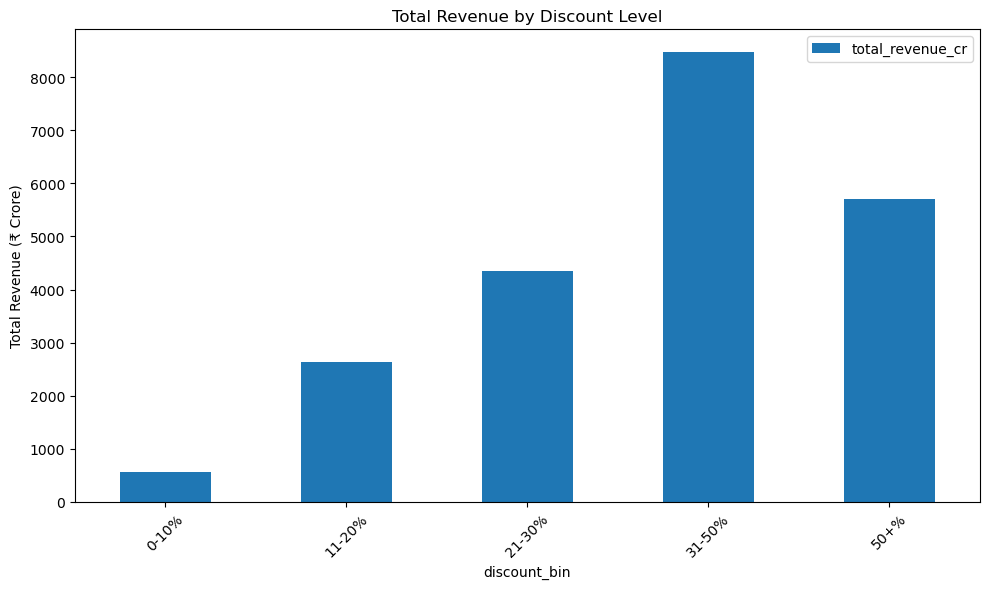

In [ ]:
                     #  3. Total revenue by discount level

import matplotlib.pyplot as plt
revenue_by_discount = df.groupby('discount_bin')['revenue'].agg(['sum', 'count', 'mean'])
revenue_by_discount['revenue_per_order'] = revenue_by_discount['sum'] / revenue_by_discount['count']
revenue_by_discount['total_revenue_cr'] = revenue_by_discount['sum'] / 1_00_000

revenue_by_discount.plot(y='total_revenue_cr', kind='bar', figsize=(10,6))
plt.title('Total Revenue by Discount Level')
plt.ylabel('Total Revenue (₹ Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_27632\1018206791.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis=df.groupby(['customer_gender','age_bins','category'])['revenue'].sum().unstack().plot(kind='bar',figsize=(20,6))


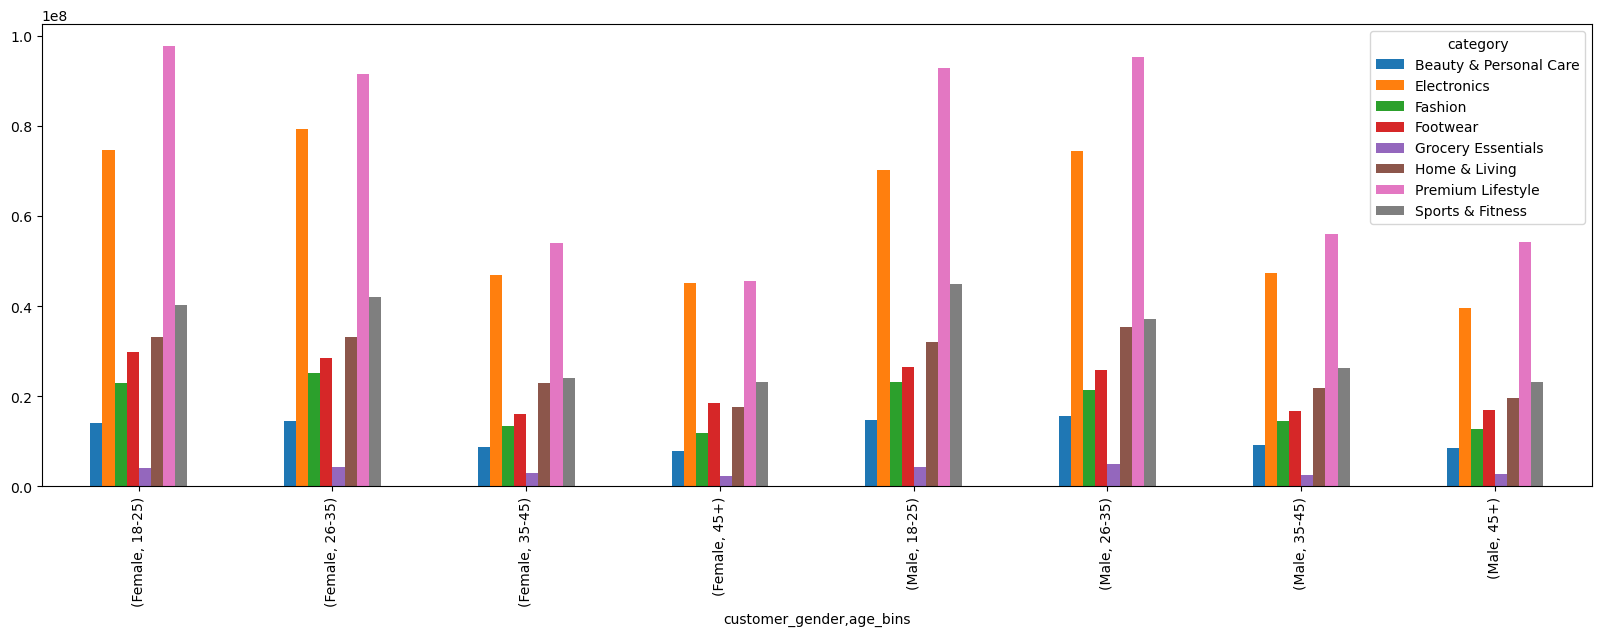

In [ ]:
#                            4. Customer Segmentation

#create AGE BIN
# Different segments buy differently → targeted marketing
import pandas as pd
df['age_bins']=pd.cut(df['customer_age'],bins=[18,25,35,45,60],labels=['18-25','26-35','35-45','45+'
])
segment_analysis=df.groupby(['customer_gender','age_bins','category'])['revenue'].sum().unstack().plot(kind='bar',figsize=(20,6))

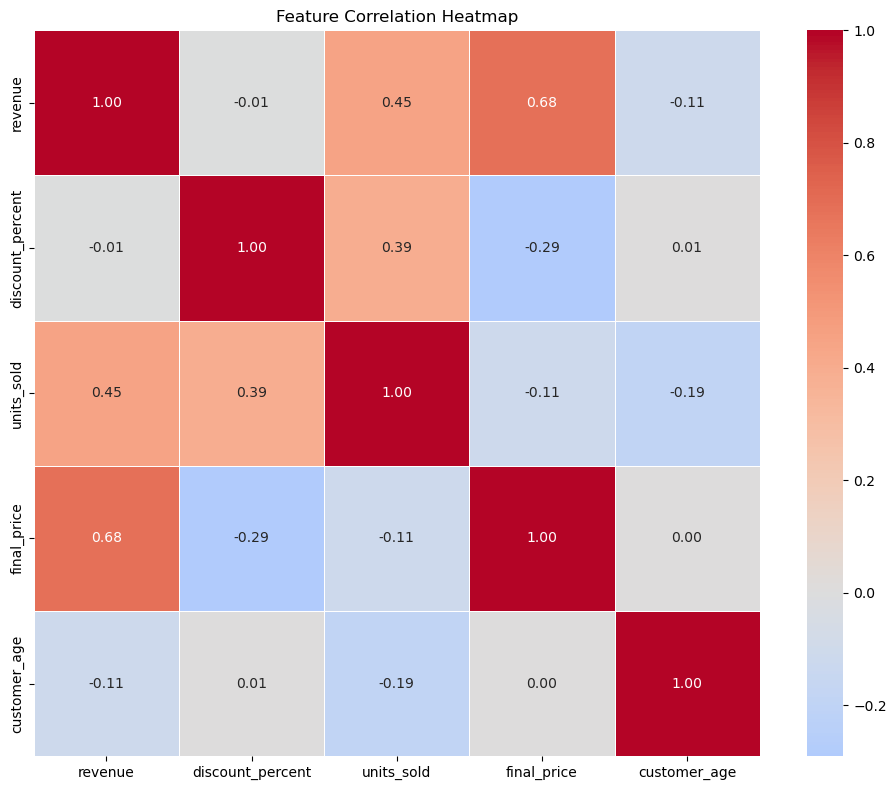

In [ ]:
                         #6. correlation among columns

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Select numeric columns (map to your actual names)
numeric_cols = ['revenue', 'discount_percent', 'units_sold', 'final_price', 'customer_age']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()



#Customer age is irrelevant for revenue prediction. Focus 100% on price + volume.
#Inference: Older customers spend more per order.
#Inference: Slight inverse relationship—cheaper items sell more units (expected)
#Inference: Discounts don't destroy revenue
#Inference: Higher selling price = higher revenue per order. Premium pricing works!
#Inference: Max  revenue comes from volume


C:\Users\HP\AppData\Local\Temp\ipykernel_27632\3040509654.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_analysis = df.groupby('price_tier').agg({


✅ Price Elasticity Analysis:
  price_tier  total_revenue  total_units  revenue_per_order
0     ₹0-200   6.524793e+07       206353       10661.426307
1   ₹200-400   1.910186e+08       206002       31212.185621
2   ₹400-700   3.477000e+08       199716       56813.730392
3  ₹700-1200   5.469500e+08       187256       89370.910621
4     ₹1200+   1.023594e+09       170861      167253.898693


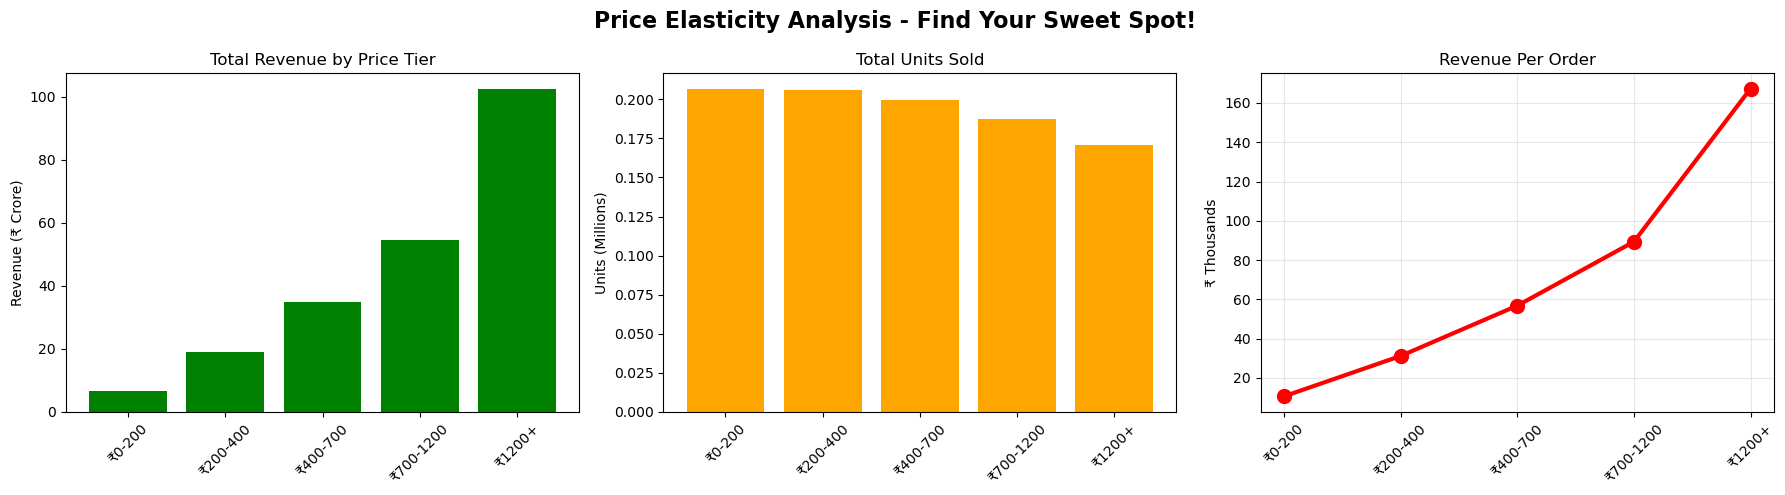

In [ ]:
                    # 7. shows exactly how price changes impact revenue.
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('indian_ecommerce.csv')


# Step 1: Create price tiers
df['price_tier'] = pd.qcut(df['final_price'], q=5, labels=['₹0-200', '₹200-400', '₹400-700', '₹700-1200', '₹1200+'])

# Step 2: 
price_analysis = df.groupby('price_tier').agg({
    'revenue': ['sum', 'mean'],
    'units_sold': ['sum', 'mean'],
    'order_id': 'count'
}).round(0)

# Step 3: 
price_analysis.columns = ['total_revenue', 'avg_revenue', 'total_units', 'avg_units', 'order_count']
price_analysis['revenue_per_order'] = price_analysis['total_revenue'] / price_analysis['order_count']

# Step 4: Clean index
price_analysis = price_analysis.reset_index()

print("✅ Price Elasticity Analysis:")
print(price_analysis[['price_tier', 'total_revenue', 'total_units', 'revenue_per_order']])

# Step 5: 3 Clear Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Total Revenue
axes[0].bar(price_analysis['price_tier'], price_analysis['total_revenue']/1e7, color='green')
axes[0].set_title('Total Revenue by Price Tier')
axes[0].set_ylabel('Revenue (₹ Crore)')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Total Units
axes[1].bar(price_analysis['price_tier'], price_analysis['total_units']/1e6, color='orange')
axes[1].set_title('Total Units Sold')
axes[1].set_ylabel('Units (Millions)')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Revenue Per Order
axes[2].plot(price_analysis['price_tier'], price_analysis['revenue_per_order']/1000, 
             marker='o', linewidth=3, markersize=10, color='red')
axes[2].set_title('Revenue Per Order')
axes[2].set_ylabel('₹ Thousands')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Price Elasticity Analysis - Find Your Sweet Spot!', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
